In [1]:
# ==========================================
# ✅ Environment Verification (XGBoost + OpenMP)
# ==========================================
import os

print("🔍 Checking XGGoost and OpenMP setup...")

try:
    import xgboost
    from xgboost import XGBClassifier
    print(f"✅ XGBoost import successfully (version {xgboost.__version__})")
except Exception as e:
    print("❌ XGBoost import failed.  Please ensure it's installed in your venv:")
    print(" pip install xgboost")
    raise e

# Check if libomp path is visible
omp_path = "/usr/local/opt/libomp/lib/libomp.dylib"
if os.path.exists(omp_path):
    print("✅ OpenMP runtime found at: {omp_path}")
else:
    print("⚠️ WArning: OpenMP (libomp.dylib) not detected at the expected path.")
    print("  Try running: brew install libomp")
    print("  Or check DYLD_LIBRARY_PATH is set correctly in ~/.zshrc")

print("Environment verification complete.\n")

🔍 Checking XGGoost and OpenMP setup...
✅ XGBoost import successfully (version 3.1.0)
✅ OpenMP runtime found at: {omp_path}
Environment verification complete.



In [2]:
# ==========================================
# 🧱 Model Training & Evaluation Notebook
# ==========================================
# Author: Kevin Woods
# Project: Customer Churn Prediction (Telco)
# ==========================================

# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

In [3]:
# Notebook Settings
sns.set(style='whitegrid', palette='pastel')
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', None)

In [5]:
# ==========================================
# 1️⃣ Load Preprocessed Data
# ==========================================
X_train = pd.read_csv('../data/processed/X_train_processed.csv')
X_test = pd.read_csv('../data/processed/X_test_processed.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')

print(f"✅ Data Loaded: {X_train.shape[0]} training samples, {X_test.shape[0]} testing samples")

# Flatten label arrays if needed
y_train = np.ravel(y_train)
y_test = np.ravel(y_test)

✅ Data Loaded: 5634 training samples, 1409 testing samples



🚀 Training Logistic Regression Model...

📊 Logistic Regression Evaluation Metrics:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409

ROC-AUC: 0.842


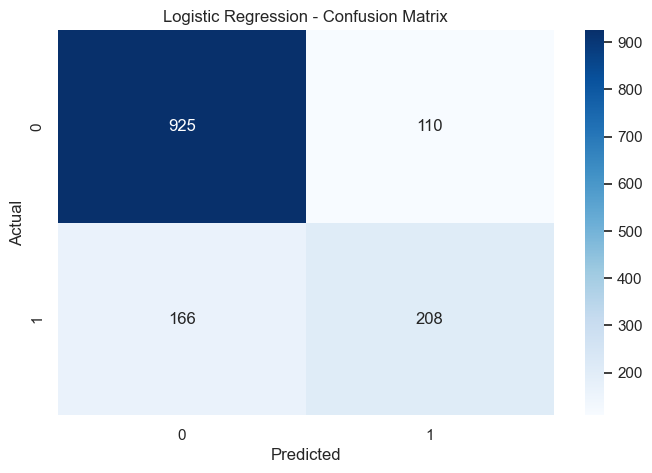

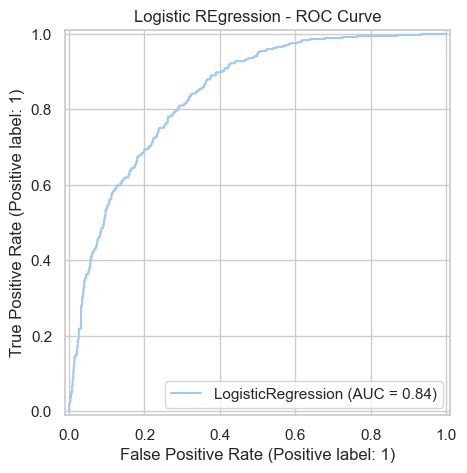

In [7]:
# ==========================================
# 2️⃣ Train Logistic Regression (Baseline)
# ==========================================
print("\n🚀 Training Logistic Regression Model...")
logreg = LogisticRegression(max_iter=500, random_state=42)
logreg.fit(X_train, y_train)

y_pred_lr = logreg.predict(X_test)
y_prob_lr = logreg.predict_proba(X_test)[:, 1]

# Evaluate Logistic Regression
print("\n📊 Logistic Regression Evaluation Metrics:")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.3f}")

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
RocCurveDisplay.from_estimator(logreg, X_test, y_test)
plt.title("Logistic REgression - ROC Curve")
plt.show()

\🚀 Training XGBoost Model...


/Users/kevinwoods/Documents/code/ai_ml/customer-churn-ml/venv/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [05:53:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 XGBost Evaluation Metrics:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.846


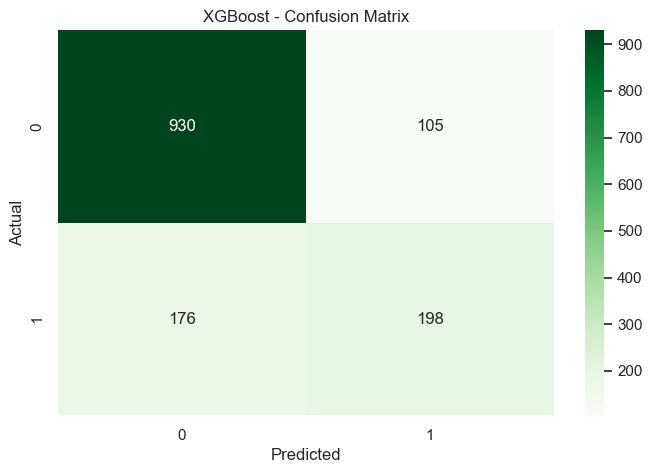

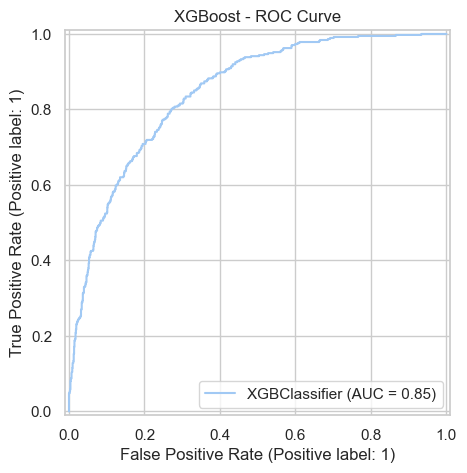

In [9]:
# ==========================================
# 3️⃣ Train XGBoost Classifier
# ==========================================
print("\🚀 Training XGBoost Model...")
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("\n📊 XGBost Evaluation Metrics:")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.3f}")

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens')
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
RocCurveDisplay.from_estimator(xgb, X_test, y_test)
plt.title("XGBoost - ROC Curve")
plt.show()


✅ Model Comparison Summary:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.804,0.654,0.556,0.601,0.842
1,XGBoost,0.801,0.653,0.556,0.601,0.846


/var/folders/tk/4jb1qzdx3wlc5pst8r770vpw0000gn/T/ipykernel_54469/367176535.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='ROC-AUC', data=results, palette='coolwarm')


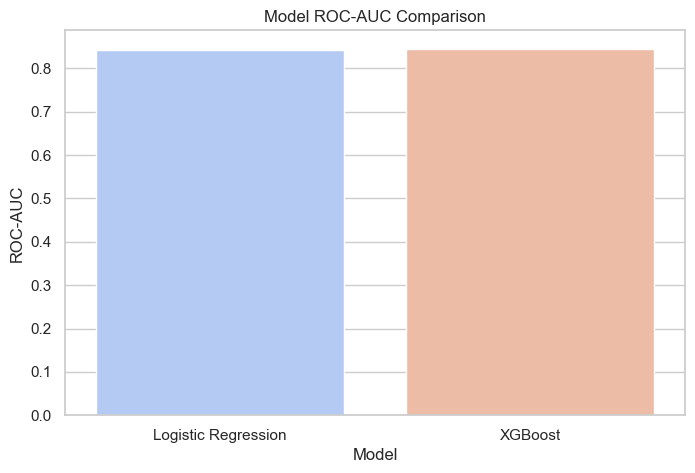

In [12]:
# ==========================================
# 4️⃣ Model Comparison Summary
# ==========================================
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_xgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr)
    ],
    'F1-Score': [
        f1_score(y_test,y_pred_lr),
        f1_score(y_test, y_pred_lr)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

print("\n✅ Model Comparison Summary:")
display(results.round(3))

sns.barplot(x='Model', y='ROC-AUC', data=results, palette='coolwarm')
plt.title("Model ROC-AUC Comparison")
plt.show()

In [14]:
# ==========================================
# 5️⃣ Save Best Model (Optional)
# ==========================================
# from joblib import dump
# dump(xgb, '../models/xgb_churn_model.joblib')
# print("\n💾 Best model saved to: ../models/xgb_churn_model.joblib")

In [ ]:
# ==========================================
# ✅ Summary
# ==========================================
print("""
🧩 Training Summary:
- Logistic Regression: simple, interpretable baseline model
- XGBoost: boosted tree ensemble for non-linear patterns
- Evaluated both with precision, recall, F1, and ROC-AUC
- Next step: model explainability with SHAP
""")